In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Find all CSV files in Kaggle input

csv_files = glob.glob(
    "/kaggle/input/**/*.csv",
    recursive=True
)

print("CSV files found:")
print("-" * 60)

for file in csv_files:
    print(file)

print("-" * 60)
print("Total CSV files:", len(csv_files))

CSV files found:
------------------------------------------------------------
/kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_test.csv
/kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_train.csv
/kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_test/sign_mnist_test.csv
/kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_train/sign_mnist_train.csv
------------------------------------------------------------
Total CSV files: 4


In [ ]:
# Load Sign Language MNIST dataset

train_file = [file for file in csv_files if "train" in file.lower()][0]
test_file = [file for file in csv_files if "test" in file.lower()][0]

train_df = pd.read_csv(train_file)
test_df = pd.read_csv(test_file)

print("Dataset loaded successfully!")

print("\nTraining data shape:", train_df.shape)
print("Testing data shape :", test_df.shape)

print("\nFirst 5 rows of training data:")
display(train_df.head())

Dataset loaded successfully!

Training data shape: (27455, 785)
Testing data shape : (7172, 785)

First 5 rows of training data:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [ ]:
# Separate labels and pixel values

y_train = train_df["label"].values
y_test = test_df["label"].values

X_train = train_df.drop("label", axis=1).values
X_test = test_df.drop("label", axis=1).values


# Normalize pixel values from 0-255 to 0-1

X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0


# Reshape images to 28x28

X_train = X_train.reshape(-1, 1, 28, 28)
X_test = X_test.reshape(-1, 1, 28, 28)


print("Preprocessing completed!")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

print("\nPixel value range:")
print("Minimum:", X_train.min())
print("Maximum:", X_train.max())

Preprocessing completed!
X_train shape: (27455, 1, 28, 28)
y_train shape: (27455,)
X_test shape : (7172, 1, 28, 28)
y_test shape : (7172,)

Pixel value range:
Minimum: 0.0
Maximum: 1.0


In [ ]:
# Convert NumPy arrays to PyTorch tensors

X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)


print("PyTorch tensors created successfully!")

print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)

print("X_test :", X_test_tensor.shape)
print("y_test :", y_test_tensor.shape)

PyTorch tensors created successfully!
X_train: torch.Size([27455, 1, 28, 28])
y_train: torch.Size([27455])
X_test : torch.Size([7172, 1, 28, 28])
y_test : torch.Size([7172])


In [ ]:
# Create TensorDatasets

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)


# Create DataLoaders

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)


print("DataLoaders created successfully!")

print("Batch size:", 64)
print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

DataLoaders created successfully!
Batch size: 64
Training batches: 429
Testing batches: 113


In [ ]:
# Define CNN model

class SignLanguageCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            # First convolution block
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Second convolution block
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                64 * 7 * 7,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                25
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x


# Create the CNN
model = SignLanguageCNN()

print("CNN model created successfully!")
print()
print(model)

CNN model created successfully!

SignLanguageCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=25, bias=True)
  )
)


In [ ]:
# Define loss function

criterion = nn.CrossEntropyLoss()


# Define optimizer

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


print("Loss function and optimizer created successfully!")
print("Loss Function: CrossEntropyLoss")
print("Optimizer: Adam")
print("Learning Rate: 0.001")

Loss function and optimizer created successfully!
Loss Function: CrossEntropyLoss
Optimizer: Adam
Learning Rate: 0.001


In [ ]:
# Train the CNN

epochs = 10

loss_history = []
accuracy_history = []


for epoch in range(epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Clear previous gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Track loss
        running_loss += loss.item()

        # Calculate accuracy
        predictions = torch.argmax(outputs, dim=1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()


    # Average loss and accuracy
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    loss_history.append(epoch_loss)
    accuracy_history.append(epoch_accuracy)


    print(
        f"Epoch [{epoch + 1}/{epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )


print("\nCNN training completed successfully!")

Epoch [1/10] Loss: 1.1386 Accuracy: 66.28%
Epoch [2/10] Loss: 0.1229 Accuracy: 96.91%
Epoch [3/10] Loss: 0.0215 Accuracy: 99.85%
Epoch [4/10] Loss: 0.0093 Accuracy: 99.92%
Epoch [5/10] Loss: 0.0044 Accuracy: 99.95%
Epoch [6/10] Loss: 0.0250 Accuracy: 99.18%
Epoch [7/10] Loss: 0.0089 Accuracy: 99.81%
Epoch [8/10] Loss: 0.0007 Accuracy: 100.00%
Epoch [9/10] Loss: 0.0004 Accuracy: 100.00%
Epoch [10/10] Loss: 0.0003 Accuracy: 100.00%

CNN training completed successfully!


In [ ]:
# Evaluate the CNN on test data

model.eval()

test_predictions = []
test_actual = []

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        test_predictions.extend(
            predictions.numpy()
        )

        test_actual.extend(
            labels.numpy()
        )


# Calculate accuracy

test_accuracy = accuracy_score(
    test_actual,
    test_predictions
)


print("CNN Model Evaluation")
print("=" * 40)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

CNN Model Evaluation
Test Accuracy: 92.43%


In [ ]:
# Classification report

print("=" * 70)
print("Classification Report - Sign Language CNN")
print("=" * 70)

print(
    classification_report(
        test_actual,
        test_predictions
    )
)

Classification Report - Sign Language CNN
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       331
           1       1.00      1.00      1.00       432
           2       1.00      1.00      1.00       310
           3       1.00      0.97      0.98       245
           4       0.96      1.00      0.98       498
           5       0.92      1.00      0.96       247
           6       0.88      0.88      0.88       348
           7       0.90      0.90      0.90       436
           8       0.93      0.91      0.92       288
          10       1.00      0.93      0.96       331
          11       0.91      1.00      0.95       209
          12       0.99      0.88      0.93       394
          13       0.92      0.86      0.89       291
          14       1.00      0.91      0.95       246
          15       0.89      1.00      0.94       347
          16       0.98      1.00      0.99       164
          17       0.67      0.79      

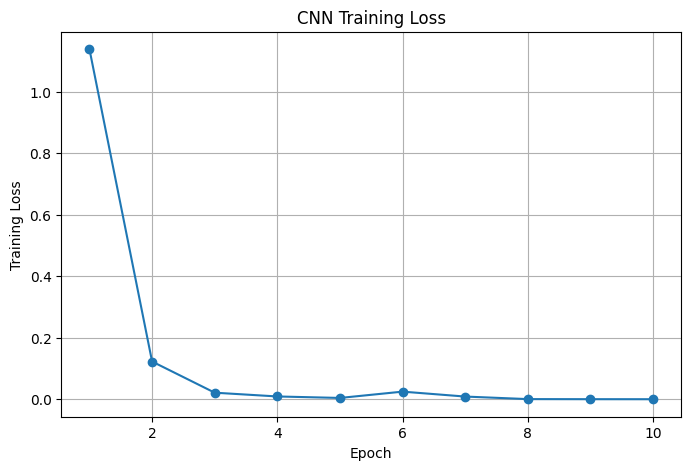

In [ ]:
# Plot training loss

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    loss_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("CNN Training Loss")

plt.grid(True)

plt.show()

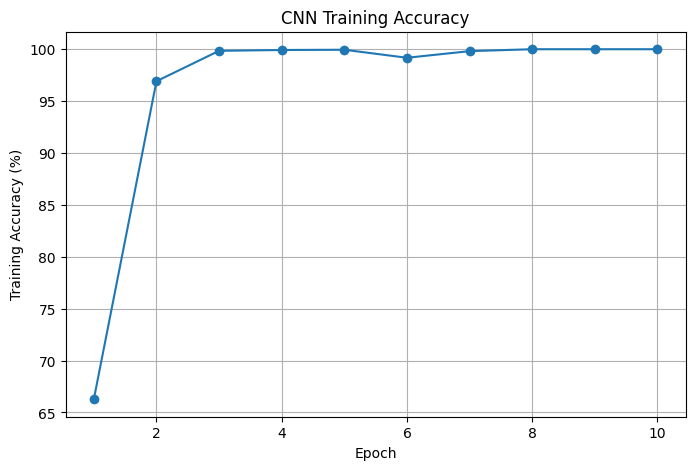

In [ ]:
# Plot training accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    accuracy_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("CNN Training Accuracy")

plt.grid(True)

plt.show()

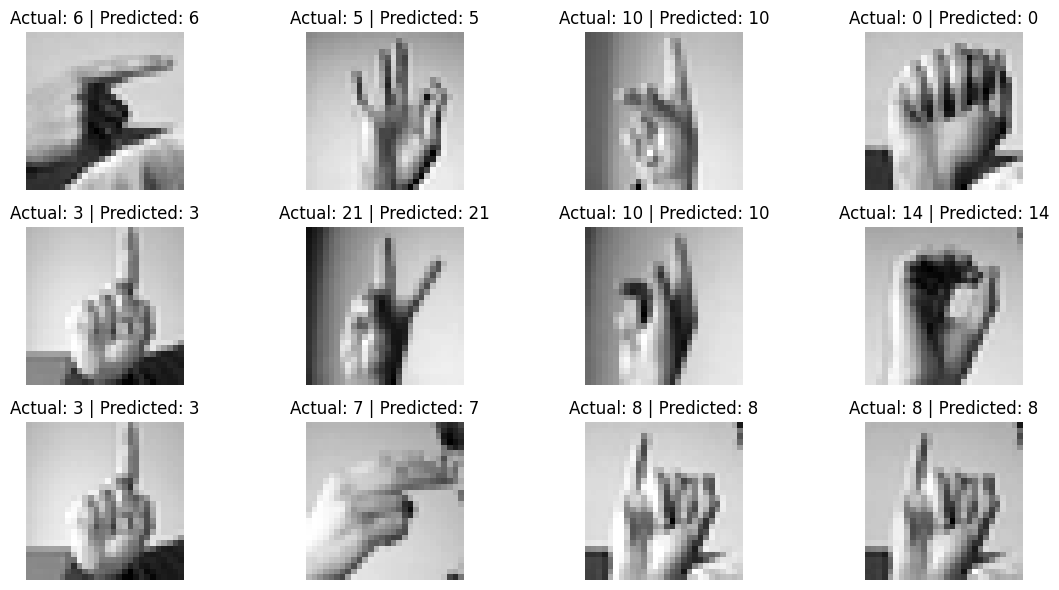

In [ ]:
# Visualize CNN predictions

model.eval()

images, labels = next(iter(test_loader))

with torch.no_grad():
    outputs = model(images)
    predictions = torch.argmax(outputs, dim=1)


plt.figure(figsize=(12, 6))

for i in range(12):

    plt.subplot(3, 4, i + 1)

    # Display image
    plt.imshow(
        images[i].squeeze(),
        cmap="gray"
    )

    actual = labels[i].item()
    predicted = predictions[i].item()

    plt.title(
        f"Actual: {actual} | Predicted: {predicted}"
    )

    plt.axis("off")


plt.tight_layout()
plt.show()

Confusion Matrix Shape: (24, 24)


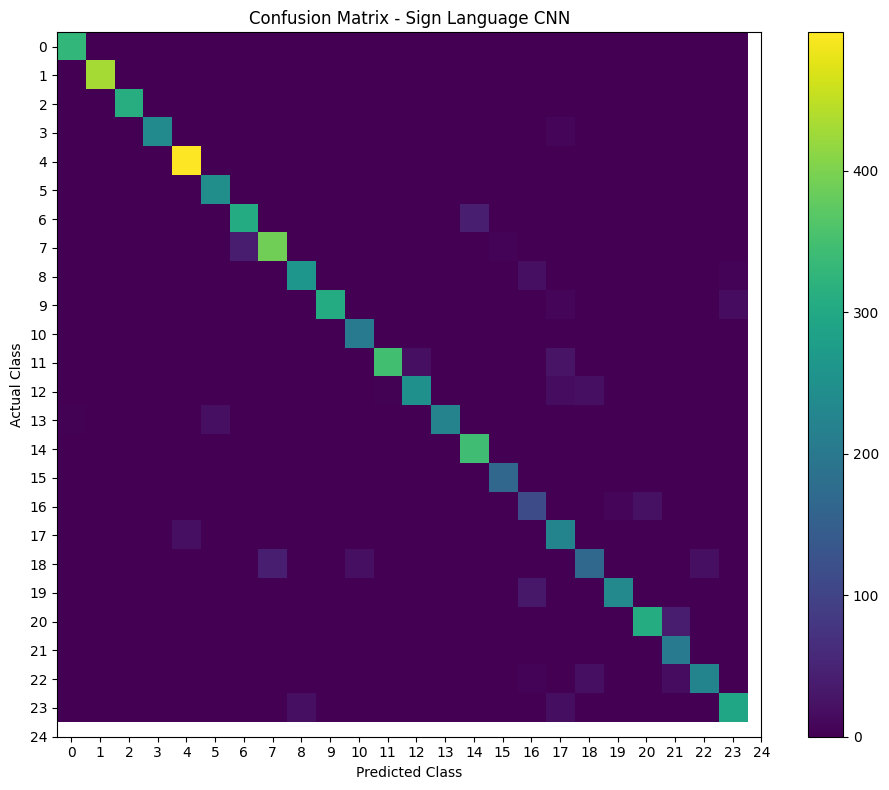

In [ ]:
# Create confusion matrix

cm = confusion_matrix(
    test_actual,
    test_predictions
)

print("Confusion Matrix Shape:", cm.shape)


# Visualize confusion matrix

plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.title("Confusion Matrix - Sign Language CNN")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(range(25))
plt.yticks(range(25))

plt.colorbar()

plt.tight_layout()
plt.show()

In [ ]:
# Final Summary and Conclusion
print("\nDataset Information:")
print("Training samples :", len(train_dataset))
print("Testing samples  :", len(test_dataset))
print("Image size       : 28 x 28")
print("Number of classes: 25")

print("\nTraining Results:")
print(f"Final Training Loss     : {loss_history[-1]:.4f}")
print(f"Final Training Accuracy : {accuracy_history[-1]:.2f}%")

print("\nTesting Results:")
print(f"Test Accuracy           : {test_accuracy * 100:.2f}%")



Dataset Information:
Training samples : 27455
Testing samples  : 7172
Image size       : 28 x 28
Number of classes: 25

Training Results:
Final Training Loss     : 0.0003
Final Training Accuracy : 100.00%

Testing Results:
Test Accuracy           : 92.43%
